# **Tugas Besar Data Mining - Part 1**

---

Anggota Kelompok:

-102022400067    Paris

-102022400137    I Putu Gede Aris Pramana

-102022400303    Bravislampa

-102022430039    Muhammad Nur Rizqi

Kelas: SI-48-03

Nama Dosen: Dita Pramesti

---

## Studi Kasus

Dalam studi kasus ini, kita akan melakukan berbagai proses Data Cleansing, Data Reduction, Missing Value Handling, dan Data Transformation pada dataset yang berkaitan dengan kendaraan BMW. Dataset ini terdiri dari informasi mengenai berbagai model BMW dengan detail spesifikasi, harga, performa, dan kondisi kendaraan dari berbagai tahun. Data ini mengumpulkan informasi tentang karakteristik teknis dan ekonomis dari kendaraan BMW yang tersedia di pasaran.

### 📄 Informasi Dataset

Dataset ini terdiri dari data kendaraan BMW dengan fitur-fitur yang menjelaskan karakteristik setiap unit kendaraan. Dataset mencakup informasi berikut:

1. **model**: Model kendaraan BMW (contoh: 5 Series, 6 Series, 1 Series, 2 Series, 3 Series, 4 Series, 7 Series, X3, dll).
2. **year**: Tahun pembuatan kendaraan (berkisar dari berbagai tahun).
3. **price**: Harga kendaraan dalam mata uang tertentu.
4. **transmission**: Jenis transmisi kendaraan (Automatic atau Manual).
5. **mileage**: Jarak tempuh kendaraan dalam mil atau kilometer.
6. **fuelType**: Jenis bahan bakar yang digunakan (Diesel, Petrol, atau Other).
7. **tax**: Jumlah pajak kendaraan tahunan.
8. **mpg**: Efisiensi bahan bakar dalam miles per gallon (MPG) - seberapa jauh kendaraan dapat menempuh perjalanan dengan satu satuan bahan bakar.
9. **engineSize**: Ukuran mesin kendaraan dalam liter - mengindikasikan kapasitas dan daya mesin.

---

### Library

Harap untuk diperhatikan, jika library terjadi error ataupun sejenisnya. Silahkan jalankan kode dibawah ini dengan menghapus tanda '#'.

In [1]:
# Jika belum punya library python dibawah ini, silahkan jalankan code dibawah ini
%pip install "pandas>=2.0.0" "numpy>=1.24.0" "scikit-learn>=1.2.2" "matplotlib>=3.7.1" "seaborn>=0.12.2"

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## **Read Data**

Pertama, kita akan membaca dataset menggunakan library pandas dan menampilkan beberapa baris awal untuk memahami struktur data.

In [2]:
import pandas as pd
df = pd.read_csv('bmw.csv')

## **Data Cleansing**

### Duplikasi data

Selanjutnya, kita akan melakukan pengecekan apakah ada data yang duplikat dalam dataset. 

Jika ada data yang duplikat, kita menghapusnya karena data duplikat dapat mempengaruhi hasil analisis.

Cek data duplikasi

In [3]:
df.info()
duplicated =df.duplicated().sum()
print("Jumlah duplikat yang ditemukan:\n", duplicated)

<class 'pandas.DataFrame'>
RangeIndex: 10781 entries, 0 to 10780
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         10781 non-null  str    
 1   year          10781 non-null  int64  
 2   price         10781 non-null  int64  
 3   transmission  10781 non-null  str    
 4   mileage       10781 non-null  int64  
 5   fuelType      10781 non-null  str    
 6   tax           10781 non-null  int64  
 7   mpg           10781 non-null  float64
 8   engineSize    10781 non-null  float64
dtypes: float64(2), int64(4), str(3)
memory usage: 758.2 KB
Jumlah duplikat yang ditemukan:
 117


Drop duplikasi data

In [4]:
df_cleaned = df.drop_duplicates()

Tampilkan Keseluruhan data untuk dicek

In [5]:
print(f"Jumlah baris sebelum drop duplikat: {len(df)}")
print(f"Jumlah baris setelah drop duplikat: {len(df_cleaned)}")
print(f"Jumlah baris yang dihapus: {len(df) - len(df_cleaned)}")
info = df_cleaned.info()

Jumlah baris sebelum drop duplikat: 10781
Jumlah baris setelah drop duplikat: 10664
Jumlah baris yang dihapus: 117
<class 'pandas.DataFrame'>
Index: 10664 entries, 0 to 10780
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         10664 non-null  str    
 1   year          10664 non-null  int64  
 2   price         10664 non-null  int64  
 3   transmission  10664 non-null  str    
 4   mileage       10664 non-null  int64  
 5   fuelType      10664 non-null  str    
 6   tax           10664 non-null  int64  
 7   mpg           10664 non-null  float64
 8   engineSize    10664 non-null  float64
dtypes: float64(2), int64(4), str(3)
memory usage: 833.1 KB


### Data Null

Periksa apakah ada kolom yabg memiliki nilai yang hilang (missing values). Kita menghapus baris-baris yang mengandung nilai kosong, karena bisa memengaruhi kualitas model jika tidak ditangani.

Melihat info dari data

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10781 entries, 0 to 10780
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         10781 non-null  str    
 1   year          10781 non-null  int64  
 2   price         10781 non-null  int64  
 3   transmission  10781 non-null  str    
 4   mileage       10781 non-null  int64  
 5   fuelType      10781 non-null  str    
 6   tax           10781 non-null  int64  
 7   mpg           10781 non-null  float64
 8   engineSize    10781 non-null  float64
dtypes: float64(2), int64(4), str(3)
memory usage: 758.2 KB


Cek total nilai null didalam tiap kolom

In [7]:
print(df.isnull().sum())

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64


Karena setelah diperiksa data sudah baik tanpa adanya kondisi null maka tidak perlu lagi untuk dihapus

Cek hasil drop nilai null

In [8]:
print(df.isnull().sum())
print(f"\nTotal baris setelah drop nilai null: {len(df)}")

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

Total baris setelah drop nilai null: 10781


### Drop kolom yang tidak di butuhkan

Periksan apakah ada kolom yang tidak relevan dengan analisis yang ingin kita lakukan

In [9]:
print(df.isnull().sum())

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64


Cek Info data

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10781 entries, 0 to 10780
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         10781 non-null  str    
 1   year          10781 non-null  int64  
 2   price         10781 non-null  int64  
 3   transmission  10781 non-null  str    
 4   mileage       10781 non-null  int64  
 5   fuelType      10781 non-null  str    
 6   tax           10781 non-null  int64  
 7   mpg           10781 non-null  float64
 8   engineSize    10781 non-null  float64
dtypes: float64(2), int64(4), str(3)
memory usage: 758.2 KB


Drop kolom yang tidak di butuhkan kolum: **'model', 'engineSize', 'tax', 'transmission', 'fueltype'**.

-model karena memiliki kardinalitas tinggi,

-engineSize karena sangat berkaitan dengan mpg karena membuat algoritma tidak stabil

-Transmission membuat hasil pengelompokan menjadi bias dan tidak valid.

-fueltype: membuat algoritma berjalan jauh lebih optimal dan akurat.

-Tax: Besaran pajak mobil biasanya tidak ditentukan secara acak, melainkan dihitung berdasarkan emisi gas buang (yang sangat berkorelasi dengan mpg), kapasitas mesin (engineSize), dan umur kendaraan (year). Artinya, informasi yang dibawa oleh tax sebenarnya sudah diwakili oleh ketiga variabel: tersebut.

In [11]:
df = df.drop(columns=['model', 'engineSize', 'transmission', 'fuelType', 'tax'])

Cek Info data

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10781 entries, 0 to 10780
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   year     10781 non-null  int64  
 1   price    10781 non-null  int64  
 2   mileage  10781 non-null  int64  
 3   mpg      10781 non-null  float64
dtypes: float64(1), int64(3)
memory usage: 337.0 KB


## **Missing Value Handling**

### Fill Missing Values by Mean

Karena tidak ada "Missing value" maka dibagian ini dapat kita lewati

Cek total nilai null pada tiap kolom

In [13]:
missingvalue = df.isnull()
print(missingvalue)

        year  price  mileage    mpg
0      False  False    False  False
1      False  False    False  False
2      False  False    False  False
3      False  False    False  False
4      False  False    False  False
...      ...    ...      ...    ...
10776  False  False    False  False
10777  False  False    False  False
10778  False  False    False  False
10779  False  False    False  False
10780  False  False    False  False

[10781 rows x 4 columns]


Buatlah grafik histogram pada semua kolom menggunakan matplotlib

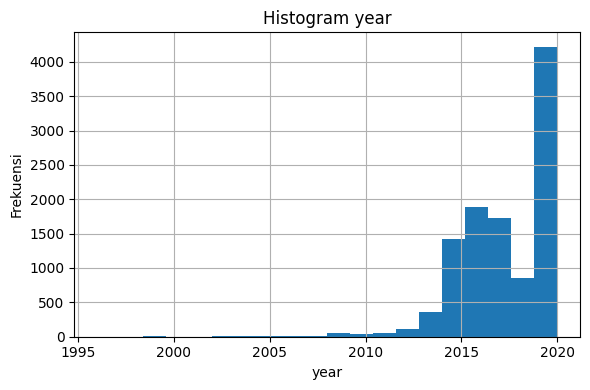

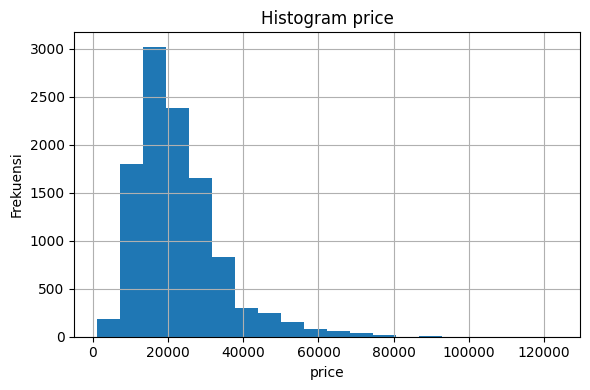

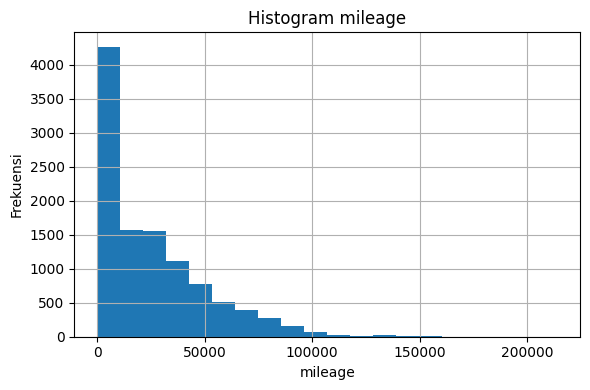

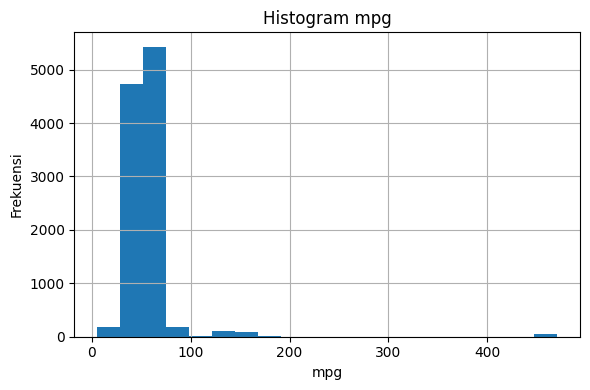

In [14]:
import matplotlib.pyplot as plt

numeric_columns = df.select_dtypes(include=['number']).columns
for col in numeric_columns:
    plt.figure(figsize=(6, 4))
    df[col].hist(bins=20)
    plt.title(f'Histogram {col}')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
    plt.tight_layout()
    plt.show()

Isi nilai null pada kolom dengan nilai mean. tidak ada "Missing value"

Cek total nilai null pada tiap kolom

In [15]:
print('Total nilai null pada kolom mean setelah imputasi:')
print(df.isnull().sum())

Total nilai null pada kolom mean setelah imputasi:
year       0
price      0
mileage    0
mpg        0
dtype: int64


Cek 10 data teratas

In [16]:
df.head(10)

,year,price,mileage,mpg
0,2014,11200,67068,57.6
1,2018,27000,14827,42.8
2,2016,16000,62794,51.4
3,2017,12750,26676,72.4
4,2014,14500,39554,50.4
5,2016,14900,35309,60.1
6,2017,16000,38538,60.1
7,2018,16250,10401,52.3
8,2017,14250,42668,62.8
9,2016,14250,36099,68.9


### Fill Missing Values by Median

jika ada nilai yang hilang, kita mengisi dengan median karena median mempresentasikan nilai tengah dari masing masing kolom dan cocok untuk kurva yang miring atau skewed.

Cek total nilai null pada tiap kolom

In [17]:
print('Total nilai null di setiap kolom untuk median:')
print(df.isnull().sum())

Total nilai null di setiap kolom untuk median:
year       0
price      0
mileage    0
mpg        0
dtype: int64


Isi nilai null pada kolom dengan nilai Median. tidak ada "Missing value"

Cek total nilai null pada tiap kolom

In [18]:
print('\nTotal nilai null di seluruh dataframe:')
print(df.isnull().sum())


Total nilai null di seluruh dataframe:
year       0
price      0
mileage    0
mpg        0
dtype: int64


Tampilkan 10 data teratas

In [19]:
df.head(10)

,year,price,mileage,mpg
0,2014,11200,67068,57.6
1,2018,27000,14827,42.8
2,2016,16000,62794,51.4
3,2017,12750,26676,72.4
4,2014,14500,39554,50.4
5,2016,14900,35309,60.1
6,2017,16000,38538,60.1
7,2018,16250,10401,52.3
8,2017,14250,42668,62.8
9,2016,14250,36099,68.9


## Outliers Handling

Outlier adalah data yang tidak lazim atau sangat berbeda dari data lainnya. Pada kasus ini, kita akan mendeteksi outlier pada semua kolom menggunakan metode Interquartile Range (IQR), dan menghapus data yang berada di luar batas.

Tampilkan ringkasan statistik dari data

In [20]:
df.describe()

,year,price,mileage,mpg
count,10781.000000,10781.000000,10781.000000,10781.000000
mean,2017.078935,22733.408867,25496.986550,56.399035
std,2.349038,11415.528189,25143.192559,31.336958
min,1996.000000,1200.000000,1.000000,5.500000
25%,2016.000000,14950.000000,5529.000000,45.600000
50%,2017.000000,20462.000000,18347.000000,53.300000
75%,2019.000000,27940.000000,38206.000000,62.800000
max,2020.000000,123456.000000,214000.000000,470.800000


Buat grafik Boxplot semua colums Outlier menggunakan library matplotlib dan pandas

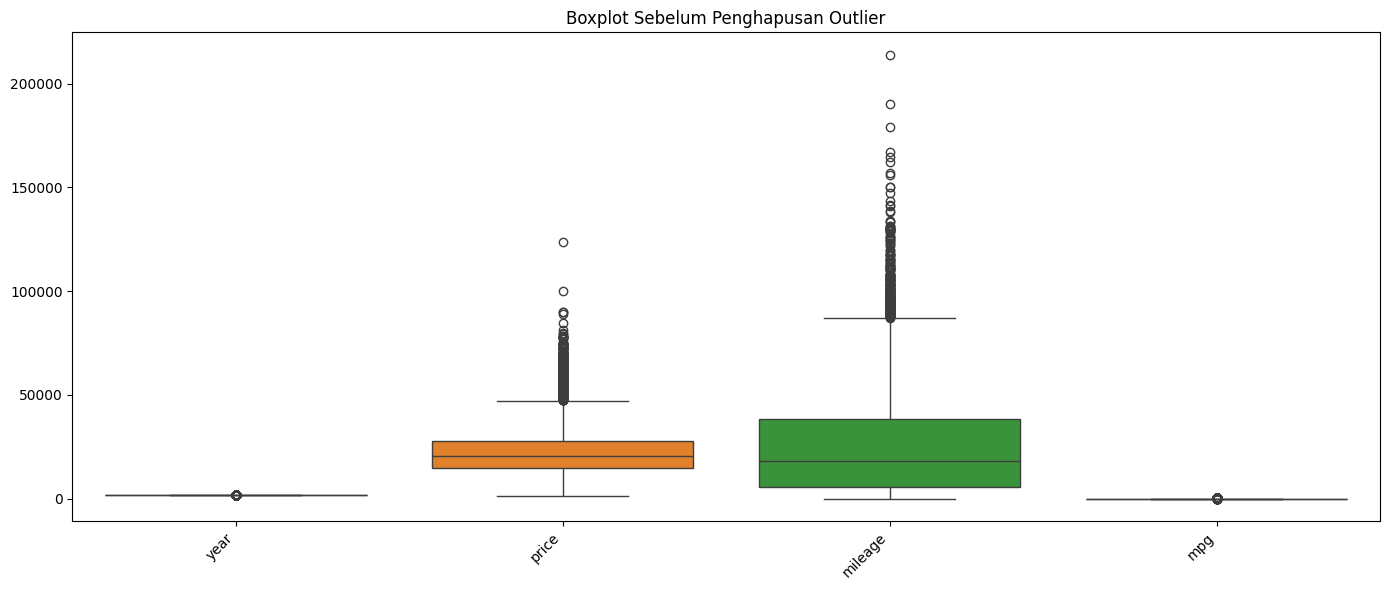

In [21]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns[:6]
plt.figure(figsize=(14, 6))
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=45, ha='right')
plt.title('Boxplot Sebelum Penghapusan Outlier')
plt.tight_layout()
plt.show()

Drop Data yang outlier

In [22]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
df_cleaned_outliers = df.copy()

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_cleaned_outliers = df_cleaned_outliers[(df_cleaned_outliers[col] >= lower_bound) & (df_cleaned_outliers[col] <= upper_bound)]

Print total baris sebelum outlier dihapus dan sesudah dihapus. Serta inisiasikan variabel data yang telah bersih ke dalam df kembali (df = variabel data yang telah bersih)

In [23]:
print(f"Total baris sebelum drop outlier: {len(df)}")
print(f"Total baris setelah drop outlier: {len(df_cleaned_outliers)}")
print(f"Jumlah baris yang dihapus: {len(df) - len(df_cleaned_outliers)}")

# Update df dengan data yang sudah bersih
df = df_cleaned_outliers

Total baris sebelum drop outlier: 10781
Total baris setelah drop outlier: 9633
Jumlah baris yang dihapus: 1148


Buat grafik Boxplot semua colums setelah pembersihan Outlier

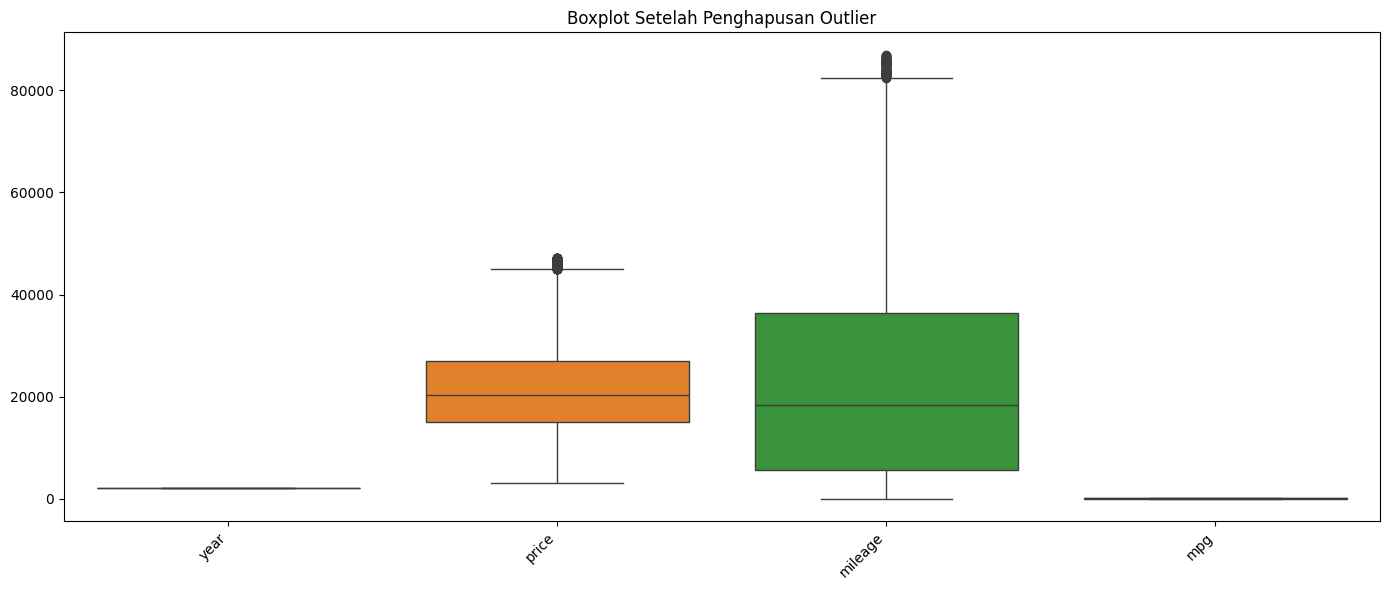

In [24]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns[:6]  # First 6 numeric columns
plt.figure(figsize=(14, 6))
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=45, ha='right')
plt.title('Boxplot Setelah Penghapusan Outlier')
plt.tight_layout()
plt.show()

Cek info data

In [25]:
df.info()

<class 'pandas.DataFrame'>
Index: 9633 entries, 0 to 10780
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   year     9633 non-null   int64  
 1   price    9633 non-null   int64  
 2   mileage  9633 non-null   int64  
 3   mpg      9633 non-null   float64
dtypes: float64(1), int64(3)
memory usage: 376.3 KB


## **Data Reduction**

### PCA

PCA digunakan untuk mengurangi dimensi data tanpa kehilangan terlalu banyak informasi. Dalam kasus ini, kita menggunakan PCA untuk mengekstrak dua komponen utama dari data yang telah dinormalisasi.

Library yang digunakan: **sklearn.decomposition (PCA), numpy, sklearn.preprocessing (StandardScaler)**

In [26]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

memilih kolom numerik yang ingin di gunakan
- year
- price
- mileage
- mpg

In [27]:
# Pilih kolom numerik untuk PCA
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
print("Kolom numerik yang digunakan:", numeric_cols.tolist())
print(f"\nJumlah fitur sebelum PCA: {len(numeric_cols)}")

# Simpan data sebelum PCA
df_before_pca = df[numeric_cols].head()
print("\nData sebelum PCA:")
print(df_before_pca)

Kolom numerik yang digunakan: ['year', 'price', 'mileage', 'mpg']

Jumlah fitur sebelum PCA: 4

Data sebelum PCA:
   year  price  mileage   mpg
0  2014  11200    67068  57.6
1  2018  27000    14827  42.8
2  2016  16000    62794  51.4
3  2017  12750    26676  72.4
4  2014  14500    39554  50.4


Lakukan normalisasi data dengan StandardScaler

In [28]:
# Normalisasi data dengan StandardScaler
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[numeric_cols])
print("Data setelah dinormalisasi (5 baris pertama):")
print(pd.DataFrame(df_scaled, columns=numeric_cols).head())

Data setelah dinormalisasi (5 baris pertama):
       year     price   mileage       mpg
0 -1.687817 -1.253965  2.057432  0.338614
1  0.403878  0.649341 -0.413456 -1.032418
2 -0.641970 -0.675745  1.855281 -0.235737
3 -0.119046 -1.067248  0.146977  1.709647
4 -1.687817 -0.856439  0.756079 -0.328374


Menerapkan PCA untuk mengurangi dimensi dari 12 dimensi menjadi 2

In [29]:
# Terapkan PCA - mengurangi dimensi menjadi 2 komponen utama
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

# Buat dataframe hasil PCA
df_pca_result = pd.DataFrame(df_pca, columns=['PC1', 'PC2'])
print("Data setelah PCA (5 baris pertama):")
print(df_pca_result.head())

# Tampilkan informasi variance
print(f"\nVariance explained oleh PC1: {pca.explained_variance_ratio_[0]:.4f}")
print(f"Variance explained oleh PC2: {pca.explained_variance_ratio_[1]:.4f}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_):.4f}")

Data setelah PCA (5 baris pertama):
        PC1       PC2
0 -2.812564 -0.845347
1  1.160688 -0.683697
2 -1.621978 -0.946301
3 -1.334863  1.508694
4 -1.662040 -1.062084

Variance explained oleh PC1: 0.6732
Variance explained oleh PC2: 0.2103
Total variance explained: 0.8835


Tampilkan 5 data sebelum dan data setelah pengimplementasian PCA

In [30]:
# Tampilkan perbandingan data sebelum dan setelah PCA
print("=== Data Sebelum PCA ===")
print(df_before_pca)
print("\n=== Data Setelah PCA ===")
print(df_pca_result.head())

# df_4NIM TERAKHIR = df_PCA (menggunakan 2 digit terakhir NIM: 67)
df_0067 = df_pca_result
print(f"\nData reduction result saved as: df_0067")
print(f"Jumlah fitur setelah PCA: {df_0067.shape[1]} (berdasarkan 2 komponen utama)")

=== Data Sebelum PCA ===
   year  price  mileage   mpg
0  2014  11200    67068  57.6
1  2018  27000    14827  42.8
2  2016  16000    62794  51.4
3  2017  12750    26676  72.4
4  2014  14500    39554  50.4

=== Data Setelah PCA ===
        PC1       PC2
0 -2.812564 -0.845347
1  1.160688 -0.683697
2 -1.621978 -0.946301
3 -1.334863  1.508694
4 -1.662040 -1.062084

Data reduction result saved as: df_0067
Jumlah fitur setelah PCA: 2 (berdasarkan 2 komponen utama)


## **Data Transformation**

### Normalization (Min-Max Scaling)

Kita menerapkan normalisasi sehingga nilainya berada di rentang 0 hingga 1. Ini penting dalam banyak model machine learning yang sensitif terhadap skala data.

Melihat data teratas

In [31]:
# Menampilkan 5 data teratas sebelum normalisasi
print("Data sebelum normalisasi:")
print(df.head())

Data sebelum normalisasi:
   year  price  mileage   mpg
0  2014  11200    67068  57.6
1  2018  27000    14827  42.8
2  2016  16000    62794  51.4
3  2017  12750    26676  72.4
4  2014  14500    39554  50.4


Import library

**sklearn.preprocessing (MinMaxScaler)**

In [32]:
from sklearn.preprocessing import MinMaxScaler

Normalisasikan data

In [33]:
# Inisialisasi MinMaxScaler
scaler = MinMaxScaler()

# Memilih kolom numerik untuk dinormalisasi
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Melakukan normalisasi (Min-Max Scaling)
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# Menampilkan data setelah normalisasi
print("\nData setelah normalisasi (Min-Max Scaling):")
print(df.head())


Data setelah normalisasi (Min-Max Scaling):
    year     price   mileage       mpg
0  0.250  0.183909  0.770894  0.540984
1  0.750  0.541586  0.170416  0.298361
2  0.500  0.292570  0.721767  0.439344
3  0.625  0.218998  0.306613  0.783607
4  0.250  0.258614  0.454637  0.422951


### Discretization (Binning)

Kolom seperti **price** dibagi menjadi beberapa kategori (Rendah, Sedang, Tinggi) untuk tujuan klasifikasi.

Tampilkan data teratas

In [34]:
print("Data sebelum proses binning:")
print(df[['price']].head())

Data sebelum proses binning:
      price
0  0.183909
1  0.541586
2  0.292570
3  0.218998
4  0.258614


Lakukan labeling dengan bins = 3 dan label berupa Rendah, Sedang, Tinggi

In [35]:
# Menentukan label kategori
kategori = ['Rendah', 'Sedang', 'Tinggi']

# Melakukan proses binning pada kolom 'price' ke dalam kolom baru bernama 'price_group'
df['price_group'] = pd.cut(df['price'], bins=3, labels=kategori)

Tampilkan data teratas

In [36]:
print("\nData setelah proses binning (Kolom price_group ditambahkan):")
print(df[['price', 'price_group']].head())


Data setelah proses binning (Kolom price_group ditambahkan):
      price price_group
0  0.183909      Rendah
1  0.541586      Sedang
2  0.292570      Rendah
3  0.218998      Rendah
4  0.258614      Rendah


### One-Hot Encoding

Kolom kategori seperti **group** yang telah dibuat sebelumnya diubah menjadi format numerik menggunakan One-Hot Encoding. Ini membantu model machine learning untuk memahami variabel kategori.

In [37]:
# Melakukan One-Hot Encoding pada kolom 'price_group'
df = pd.get_dummies(df, columns=['price_group'], prefix='price')

# Mengubah tipe boolean True/False menjadi 1/0 (Opsional, tergantung model algoritma)
df[['price_Rendah', 'price_Sedang', 'price_Tinggi']] = df[['price_Rendah', 'price_Sedang', 'price_Tinggi']].astype(int)

# Tampilkan data teratas setelah di-encode
print("Data setelah One-Hot Encoding:")
print(df.head())

Data setelah One-Hot Encoding:
    year     price   mileage       mpg  price_Rendah  price_Sedang  \
0  0.250  0.183909  0.770894  0.540984             1             0   
1  0.750  0.541586  0.170416  0.298361             0             1   
2  0.500  0.292570  0.721767  0.439344             1             0   
3  0.625  0.218998  0.306613  0.783607             1             0   
4  0.250  0.258614  0.454637  0.422951             1             0   

   price_Tinggi  
0             0  
1             0  
2             0  
3             0  
4             0  


In [38]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
# 1. Memilih hanya kolom numerik untuk clustering
# Pastikan semua data kategorik sudah di-drop atau di-encode
X = df.select_dtypes(include=['number', 'int32', 'int64', 'float64'])

Berikan kesimpulan yang mencakup semua proses yang telah dilakukan

### Clustering K-Means

In [40]:
# 2. Standardisasi data menggunakan StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data setelah standardisasi:")
print(f"Shape: {X_scaled.shape}")
print(f"Mean: {X_scaled.mean(axis=0)[:5]}...")
print(f"Std Dev: {X_scaled.std(axis=0)[:5]}...")

Data setelah standardisasi:
Shape: (9633, 7)
Mean: [ 1.29819912e-16 -4.48468788e-16 -1.18018102e-16  1.77027153e-16
  4.72072408e-17]...
Std Dev: [1. 1. 1. 1. 1.]...


In [41]:
# 3. Menggunakan Elbow Method untuk menentukan jumlah cluster optimal
inertias = []
silhouette_scores = []
cluster_range = range(2, 11)

from sklearn.metrics import silhouette_score

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

print("Inertias untuk berbagai jumlah cluster:")
for k, inertia in zip(cluster_range, inertias):
    print(f"K={k}: Inertia={inertia:.2f}, Silhouette Score={silhouette_scores[k-2]:.4f}")

Inertias untuk berbagai jumlah cluster:
K=2: Inertia=35384.65, Silhouette Score=0.4673
K=3: Inertia=19866.58, Silhouette Score=0.5500
K=4: Inertia=16223.66, Silhouette Score=0.4382
K=5: Inertia=13323.07, Silhouette Score=0.3788
K=6: Inertia=11567.43, Silhouette Score=0.3708
K=7: Inertia=10097.08, Silhouette Score=0.3696
K=8: Inertia=9403.98, Silhouette Score=0.3595
K=9: Inertia=8752.47, Silhouette Score=0.3424
K=10: Inertia=8150.79, Silhouette Score=0.3160


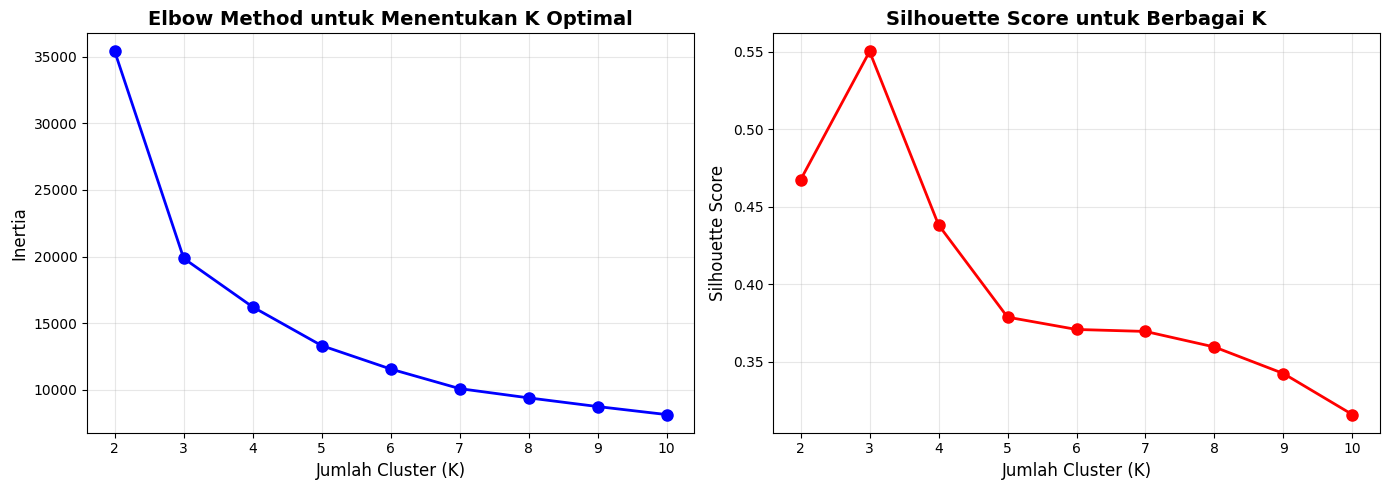

Saran: Dari Elbow Curve dan Silhouette Score, K optimal umumnya berada di antara 3-5 cluster


In [42]:
# Visualisasi Elbow Curve dan Silhouette Score
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Curve
axes[0].plot(cluster_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Jumlah Cluster (K)', fontsize=12)
axes[0].set_ylabel('Inertia', fontsize=12)
axes[0].set_title('Elbow Method untuk Menentukan K Optimal', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Silhouette Score
axes[1].plot(cluster_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Jumlah Cluster (K)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score untuk Berbagai K', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Saran: Dari Elbow Curve dan Silhouette Score, K optimal umumnya berada di antara 3-5 cluster")

In [43]:
# 4. Melakukan K-Means clustering dengan K=3 (optimal)
optimal_k = 3
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled)

# Menambahkan cluster labels ke dataframe asli
df['Cluster'] = cluster_labels

print(f"K-Means Clustering dengan K={optimal_k} selesai!")
print(f"\nDistribusi anggota cluster:")
print(df['Cluster'].value_counts().sort_index())
print(f"\nCluster Centers (berdasarkan data yang discale):")
print(kmeans_final.cluster_centers_)

K-Means Clustering dengan K=3 selesai!

Distribusi anggota cluster:
Cluster
0    3657
1    4912
2    1064
Name: count, dtype: int64

Cluster Centers (berdasarkan data yang discale):
[[-0.8533128  -0.96246337  0.81956627  0.56635714  1.27607604 -1.01747107
  -0.35237553]
 [ 0.43762484  0.29813701 -0.43519134 -0.21528033 -0.7808172   0.97873679
  -0.35237553]
 [ 0.91254859  1.93165371 -0.80779509 -0.95273599 -0.78123684 -1.02130019
   2.8378815 ]]


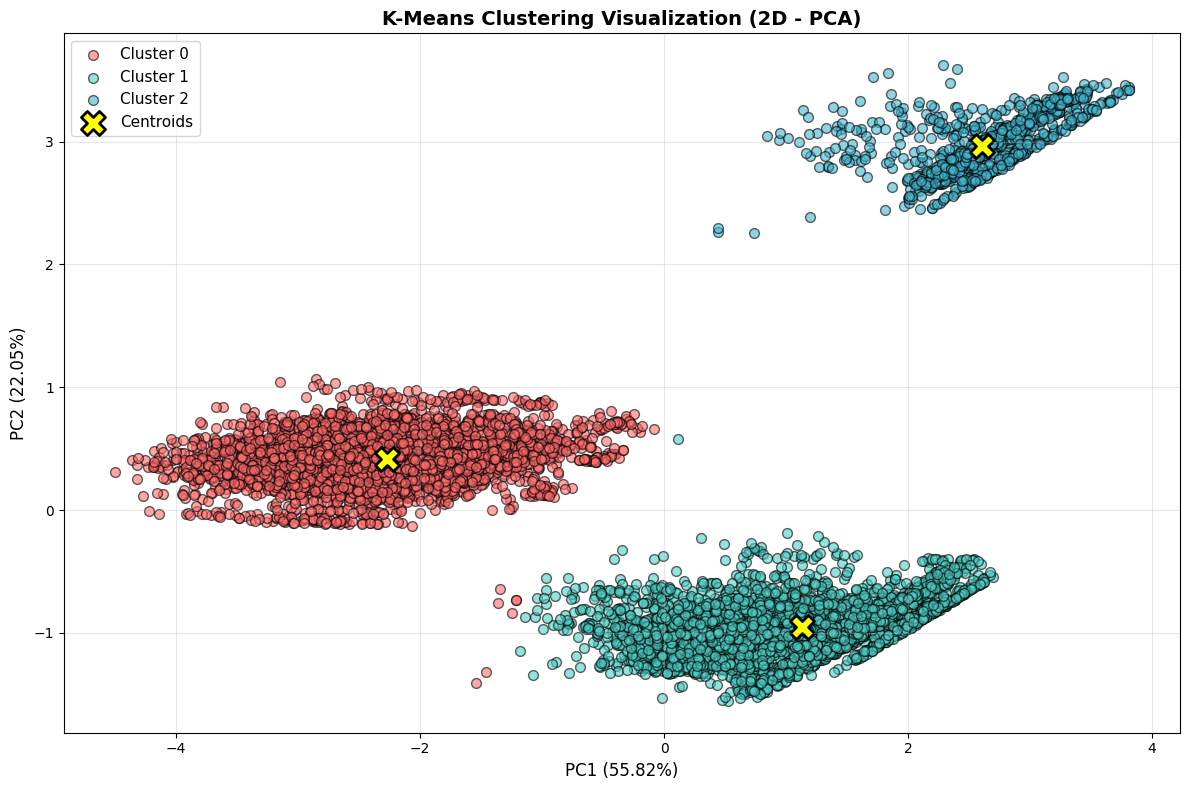

Explained variance ratio PC1: 0.5582
Explained variance ratio PC2: 0.2205
Total variance explained: 0.7788


In [44]:
# 5. Visualisasi Clustering menggunakan PCA untuk 2D projection
from sklearn.decomposition import PCA

pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

# Mentransformasi cluster centers ke dalam PCA space
centers_pca_2d = pca_2d.transform(kmeans_final.cluster_centers_)

# Membuat scatter plot
plt.figure(figsize=(12, 8))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
cluster_names = ['Cluster 0', 'Cluster 1', 'Cluster 2']

for i in range(optimal_k):
    cluster_points = X_pca_2d[cluster_labels == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], 
                c=colors[i], label=cluster_names[i], s=50, alpha=0.6, edgecolors='black')

# Plot cluster centers
plt.scatter(centers_pca_2d[:, 0], centers_pca_2d[:, 1], 
            c='yellow', marker='X', s=300, edgecolors='black', linewidth=2, label='Centroids')

plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.2f}%)', fontsize=12)
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.2f}%)', fontsize=12)
plt.title(f'K-Means Clustering Visualization (2D - PCA)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Explained variance ratio PC1: {pca_2d.explained_variance_ratio_[0]:.4f}")
print(f"Explained variance ratio PC2: {pca_2d.explained_variance_ratio_[1]:.4f}")
print(f"Total variance explained: {sum(pca_2d.explained_variance_ratio_):.4f}")

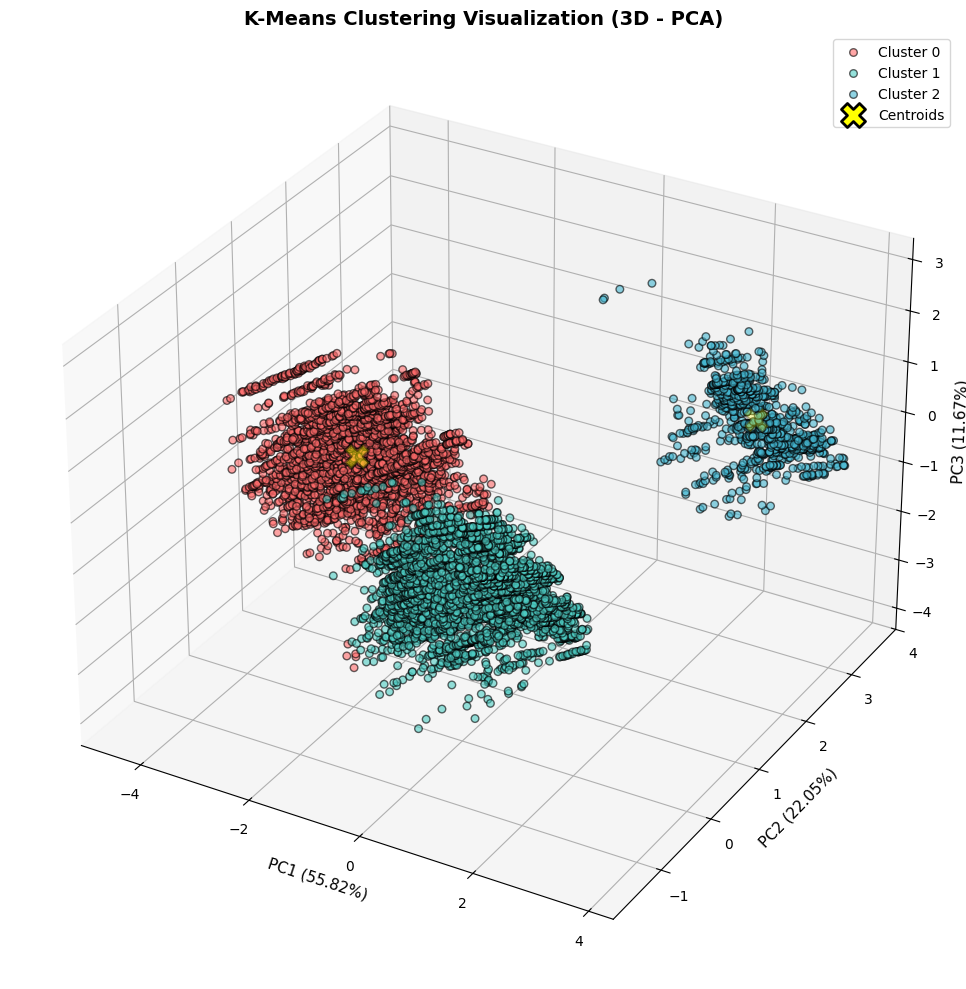

Explained variance ratio PC1: 0.5582
Explained variance ratio PC2: 0.2205
Explained variance ratio PC3: 0.1167
Total variance explained by 3 PCs: 0.8954


In [45]:
# 6. Visualisasi 3D menggunakan PCA
from mpl_toolkits.mplot3d import Axes3D

pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)
centers_pca_3d = pca_3d.transform(kmeans_final.cluster_centers_)

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
cluster_names = ['Cluster 0', 'Cluster 1', 'Cluster 2']

for i in range(optimal_k):
    cluster_points = X_pca_3d[cluster_labels == i]
    ax.scatter(cluster_points[:, 0], cluster_points[:, 1], cluster_points[:, 2],
               c=colors[i], label=cluster_names[i], s=30, alpha=0.6, edgecolors='black')

# Plot cluster centers
ax.scatter(centers_pca_3d[:, 0], centers_pca_3d[:, 1], centers_pca_3d[:, 2],
           c='yellow', marker='X', s=300, edgecolors='black', linewidth=2, label='Centroids')

ax.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]*100:.2f}%)', fontsize=11)
ax.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]*100:.2f}%)', fontsize=11)
ax.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]*100:.2f}%)', fontsize=11)
ax.set_title(f'K-Means Clustering Visualization (3D - PCA)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f"Explained variance ratio PC1: {pca_3d.explained_variance_ratio_[0]:.4f}")
print(f"Explained variance ratio PC2: {pca_3d.explained_variance_ratio_[1]:.4f}")
print(f"Explained variance ratio PC3: {pca_3d.explained_variance_ratio_[2]:.4f}")
print(f"Total variance explained by 3 PCs: {sum(pca_3d.explained_variance_ratio_):.4f}")

In [47]:
# 7. Analisis Statistik Per Cluster
cluster_stats = df.groupby('Cluster')[['price', 'mileage', 'mpg', 'year']].agg(['mean', 'std', 'min', 'max'])
print("=" * 80)
print("STATISTIK KARAKTERISTIK SETIAP CLUSTER")
print("=" * 80)
print(cluster_stats)

# Menampilkan secara lebih readable
print("\n" + "=" * 80)
print("RINGKASAN KARAKTERISTIK CLUSTER")
print("=" * 80)

for cluster in range(optimal_k):
    cluster_data = df[df['Cluster'] == cluster]
    print(f"\nCluster {cluster} (Total: {len(cluster_data)} data)")
    print(f"  - Harga rata-rata: ${cluster_data['price'].mean():.2f}")
    print(f"  - Jarak tempuh rata-rata: {cluster_data['mileage'].mean():.2f} km")
    print(f"  - Efisiensi bahan bakar rata-rata: {cluster_data['mpg'].mean():.2f} MPG")
    print(f"  - Tahun rata-rata: {cluster_data['year'].mean():.0f}")

STATISTIK KARAKTERISTIK SETIAP CLUSTER
            price                                 mileage                      \
             mean       std       min       max      mean       std       min   
Cluster                                                                         
0        0.238689  0.059877  0.000000  0.466858  0.470066  0.226127  0.000126   
1        0.475586  0.093131  0.201906  0.666297  0.165134  0.163790  0.000000   
2        0.782563  0.093190  0.666999  1.000000  0.074583  0.093074  0.000046   

                        mpg                               year            \
              max      mean       std       min  max      mean       std   
Cluster                                                                    
0        1.000000  0.581286  0.160043  0.140984  1.0  0.449480  0.188508   
1        0.958068  0.442964  0.149561  0.000000  1.0  0.758067  0.174481   
2        0.731721  0.312461  0.150456  0.013115  1.0  0.871593  0.116680   

                 

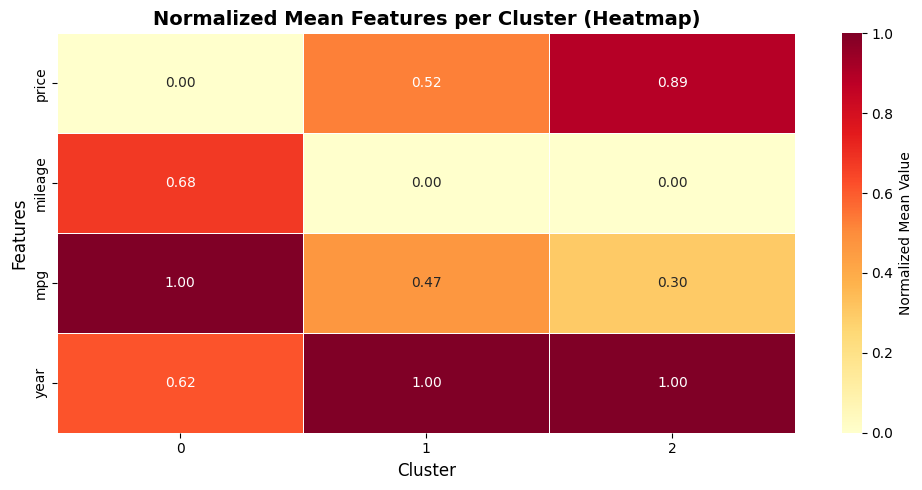


Normalized Mean Features per Cluster:
            price   mileage       mpg      year
Cluster                                        
0        0.000000  0.675363  1.000000  0.615275
1        0.523587  0.000000  0.468570  1.000000
2        0.888294  0.000000  0.298464  1.000000


In [48]:
# 8. Heatmap untuk perbandingan rata-rata fitur antar cluster
cluster_means = df.groupby('Cluster')[['price', 'mileage', 'mpg', 'year']].mean()

# Normalisasi data untuk visualisasi lebih baik
from sklearn.preprocessing import MinMaxScaler
scaler_viz = MinMaxScaler()
cluster_means_normalized = pd.DataFrame(
    scaler_viz.fit_transform(cluster_means.T).T,
    columns=cluster_means.columns,
    index=cluster_means.index
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(cluster_means_normalized.T, annot=True, fmt='.2f', cmap='YlOrRd', 
            cbar_kws={'label': 'Normalized Mean Value'}, ax=ax, linewidths=0.5)
ax.set_title('Normalized Mean Features per Cluster (Heatmap)', fontsize=14, fontweight='bold')
ax.set_xlabel('Cluster', fontsize=12)
ax.set_ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

print("\nNormalized Mean Features per Cluster:")
print(cluster_means_normalized)

C:\Users\LOQ\AppData\Local\Temp\ipykernel_8472\3628583760.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Cluster', y=feature, ax=axes_flat[idx], palette='Set2')
C:\Users\LOQ\AppData\Local\Temp\ipykernel_8472\3628583760.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Cluster', y=feature, ax=axes_flat[idx], palette='Set2')
C:\Users\LOQ\AppData\Local\Temp\ipykernel_8472\3628583760.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Cluster', y=feature, ax=axes_flat[idx], palette='Set2')
C:\Users\LOQ\

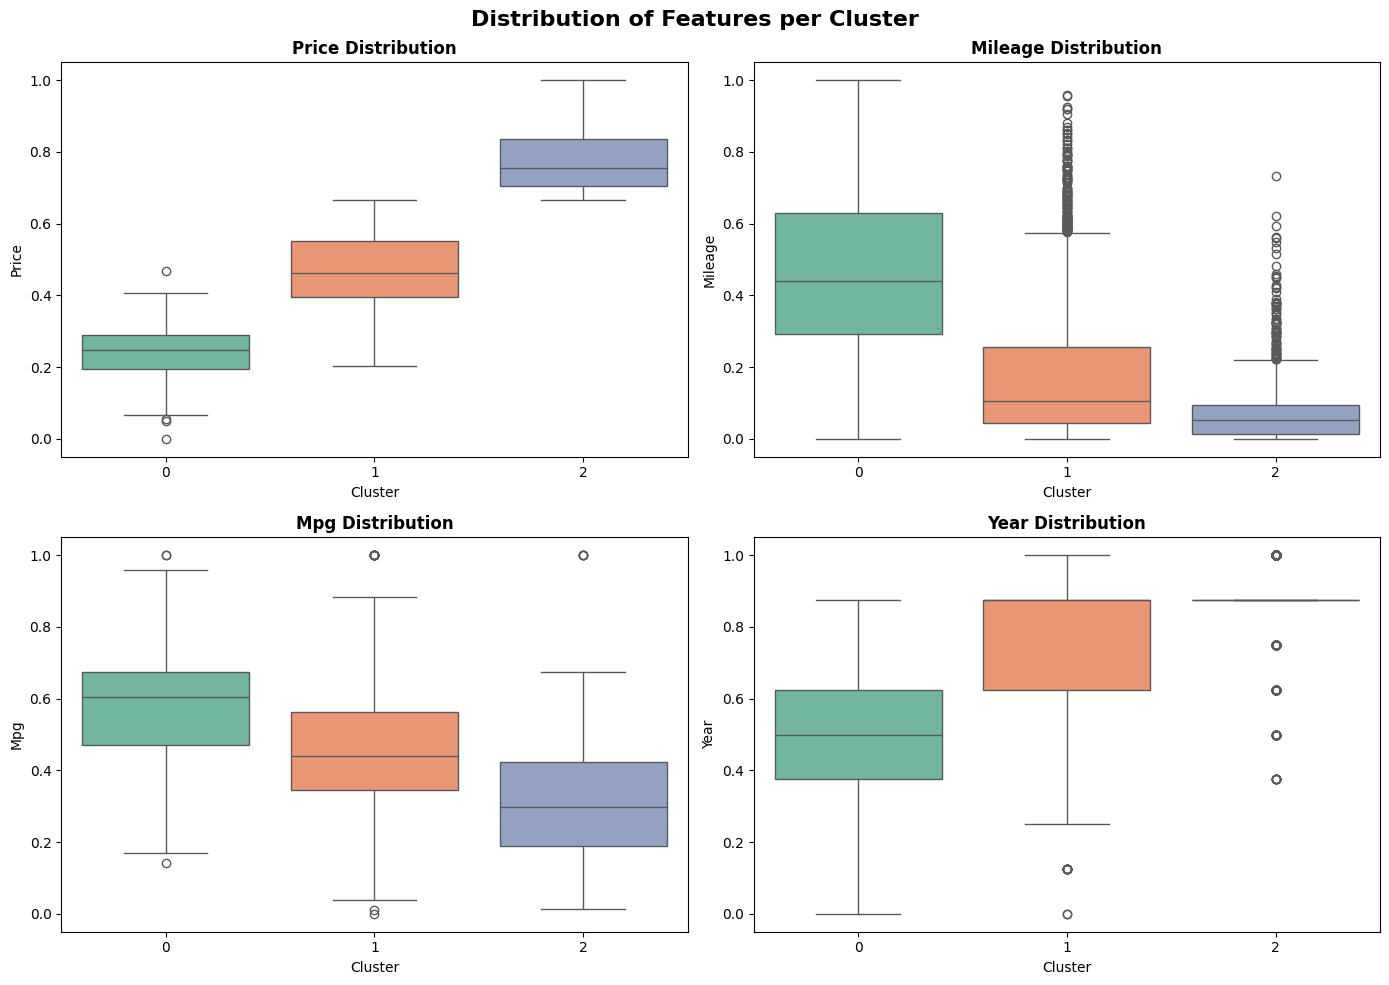

Box plot menunjukkan distribusi setiap fitur untuk setiap cluster


In [49]:
# 9. Box plot untuk visualisasi distribusi fitur per cluster
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribution of Features per Cluster', fontsize=16, fontweight='bold')

features_to_plot = ['price', 'mileage', 'mpg', 'year']
axes_flat = axes.flatten()

for idx, feature in enumerate(features_to_plot):
    sns.boxplot(data=df, x='Cluster', y=feature, ax=axes_flat[idx], palette='Set2')
    axes_flat[idx].set_title(f'{feature.capitalize()} Distribution', fontsize=12, fontweight='bold')
    axes_flat[idx].set_xlabel('Cluster')
    axes_flat[idx].set_ylabel(feature.capitalize())

plt.tight_layout()
plt.show()

print("Box plot menunjukkan distribusi setiap fitur untuk setiap cluster")

In [51]:
# 10. Menampilkan contoh data dengan cluster assignment
print("=" * 100)
print("CONTOH DATA DENGAN CLUSTER ASSIGNMENT")
print("=" * 100)

sample_display = df[['year', 'price', 'mileage', 'mpg', 'Cluster']].head(20)
print(sample_display)

print("\n" + "=" * 100)
print("RINGKASAN HASIL CLUSTERING")
print("=" * 100)
print(f"Total data: {len(df)}")
print(f"Jumlah cluster: {optimal_k}")
print(f"Silhouette Score: {silhouette_scores[optimal_k-2]:.4f}")

for i in range(optimal_k):
    count = (df['Cluster'] == i).sum()
    percentage = (count / len(df)) * 100
    print(f"  Cluster {i}: {count} data ({percentage:.2f}%)")

CONTOH DATA DENGAN CLUSTER ASSIGNMENT
     year     price   mileage       mpg  Cluster
0   0.250  0.183909  0.770894  0.540984        0
1   0.750  0.541586  0.170416  0.298361        1
2   0.500  0.292570  0.721767  0.439344        0
3   0.625  0.218998  0.306613  0.783607        0
4   0.250  0.258614  0.454637  0.422951        0
5   0.500  0.267669  0.405844  0.581967        0
6   0.625  0.292570  0.442959  0.581967        0
7   0.750  0.298230  0.119542  0.454098        0
8   0.625  0.252954  0.490431  0.626230        0
9   0.500  0.252954  0.414924  0.726230        0
10  0.625  0.281251  0.860998  0.454098        0
11  0.625  0.197492  0.342981  0.726230        0
12  0.500  0.281251  0.894516  0.486885        0
13  0.375  0.168063  0.361705  0.726230        0
14  0.625  0.428397  0.219037  0.486885        1
15  0.625  0.303889  0.190450  0.562295        0
17  0.625  0.292570  0.522477  0.649180        0
18  0.625  0.281251  0.262198  0.726230        0
19  0.250  0.247295  0.544225  

#### Contoh Data dengan Cluster Assignment

#### Box Plot Perbandingan Cluster

#### Heatmap Perbandingan Rata-rata Cluster

#### Analisis Statistik Per Cluster

#### Visualisasi Hasil Clustering 3D menggunakan PCA

#### Visualisasi Hasil Clustering 2D menggunakan PCA

#### Melakukan K-Means Clustering dengan K=3

#### Visualisasi Elbow Curve dan Silhouette Score

#### Elbow Method untuk Menentukan Jumlah Cluster Optimal

#### Standardisasi Data untuk Clustering